## LSTM Model for Energy Forecasting

To complement the Random Forest baseline, we implement a Long Short-Term Memory (LSTM) neural network for time-series forecasting.

LSTM models are a type of recurrent neural network designed to learn long-term dependencies in sequential data. Unlike tree-based models, LSTMs process data as ordered sequences, making them well-suited for energy forecasting tasks.

In this project, the LSTM model is used to predict:
- Photovoltaic (PV) energy generation
- Household grid import (energy consumption)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [3]:
df_usage = pd.read_csv("../data/residential3_cleaned.csv")

if "utc_timestamp" in df_usage.columns:
    df_usage["utc_timestamp"] = pd.to_datetime(df_usage["utc_timestamp"])
    df_usage = df_usage.set_index("utc_timestamp")
else:
    df_usage.iloc[:, 0] = pd.to_datetime(df_usage.iloc[:, 0])
    df_usage = df_usage.set_index(df_usage.columns[0])

df_usage = df_usage.sort_index()

print("Start:", df_usage.index.min())
print("End:", df_usage.index.max())
print("Duration:", df_usage.index.max() - df_usage.index.min())
print("Rows:", len(df_usage))

df_usage.head()

Start: 2016-02-28 17:30:00+00:00
End: 2017-07-08 15:45:00+00:00
Duration: 495 days 22:15:00
Rows: 47610


,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine,hour
utc_timestamp,,,,,,,,,
2016-02-28 17:30:00+00:00,0.018,0.001,0.0,0.0,0.145,0.0,0.012,0.0,17
2016-02-28 17:45:00+00:00,0.018,0.000,0.0,0.0,0.180,0.0,0.005,0.0,17
2016-02-28 18:00:00+00:00,0.018,0.001,0.0,0.0,0.180,0.0,0.000,0.0,18
2016-02-28 18:15:00+00:00,0.018,0.001,0.0,0.0,0.238,0.0,0.000,0.0,18
2016-02-28 18:30:00+00:00,0.018,0.000,0.0,0.0,0.230,0.0,0.000,0.0,18


In [4]:
grid_col = "DE_KN_residential3_grid_import"
pv_col = "DE_KN_residential3_pv"

appliance_cols = [
    "DE_KN_residential3_washing_machine",
    "DE_KN_residential3_dishwasher",
    "DE_KN_residential3_freezer",
    "DE_KN_residential3_circulation_pump",
    "DE_KN_residential3_refrigerator"
]

required_cols = [grid_col, pv_col] + appliance_cols

missing_cols = [col for col in required_cols if col not in df_usage.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df_usage = df_usage[required_cols].copy()

# Cleaning Outliers

In [5]:
print("PV before cleaning:")
print(df_usage[pv_col].describe())
print(df_usage[pv_col].quantile([0.95, 0.99, 0.999, 1.0]))

pv_outlier_mask = df_usage[pv_col] >= 2

print("Number of PV outliers:", pv_outlier_mask.sum())
display(df_usage.loc[pv_outlier_mask, [pv_col]].head(20))

df_usage.loc[pv_outlier_mask, pv_col] = np.nan
df_usage[pv_col] = df_usage[pv_col].interpolate(method="time")
df_usage[pv_col] = df_usage[pv_col].fillna(0)

print("PV after cleaning:")
print(df_usage[pv_col].describe())

PV before cleaning:
count    47610.000000
mean         0.152820
std          0.793335
min          0.000000
25%          0.000000
50%          0.000000
75%          0.206000
max         73.306000
Name: DE_KN_residential3_pv, dtype: float64
0.950     0.701
0.990     0.823
0.999     0.915
1.000    73.306
Name: DE_KN_residential3_pv, dtype: float64
Number of PV outliers: 9


,DE_KN_residential3_pv
utc_timestamp,
2017-04-08 01:45:00+00:00,73.305
2017-04-10 01:45:00+00:00,73.305
2017-04-11 01:45:00+00:00,73.305
2017-04-12 01:45:00+00:00,73.306
2017-04-13 01:45:00+00:00,73.305
2017-04-19 00:00:00+00:00,13.176
2017-04-19 00:15:00+00:00,13.177
2017-04-21 00:00:00+00:00,13.176
2017-04-21 00:15:00+00:00,13.177


PV after cleaning:
count    47610.000000
mean         0.144015
std          0.230335
min          0.000000
25%          0.000000
50%          0.000000
75%          0.206000
max          0.989000
Name: DE_KN_residential3_pv, dtype: float64


# Feature Engineering

In [6]:
pv_lstm_features = [
    "pv_current",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

grid_lstm_features_no_appliances = [
    "cons_current",
    "pv_current",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos"
]

grid_lstm_features_with_appliances = grid_lstm_features_no_appliances + appliance_cols

# Train-test

In [7]:
df_model = df_usage.copy()

# Current values
df_model["pv_current"] = df_model[pv_col]
df_model["cons_current"] = df_model[grid_col]

# Time features
df_model["hour_sin"] = np.sin(2 * np.pi * df_model.index.hour / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model.index.hour / 24)

df_model["doy_sin"] = np.sin(2 * np.pi * df_model.index.dayofyear / 365)
df_model["doy_cos"] = np.cos(2 * np.pi * df_model.index.dayofyear / 365)

# Targets: next 15-minute interval
df_model["pv_target"] = df_model[pv_col].shift(-1)
df_model["grid_import_target"] = df_model[grid_col].shift(-1)

# Drop last row because target shift creates NaN
df_model = df_model.dropna()

print("df_model shape:", df_model.shape)
df_model.head()

df_model shape: (47609, 15)


,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_washing_machine,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_circulation_pump,DE_KN_residential3_refrigerator,pv_current,cons_current,hour_sin,hour_cos,doy_sin,doy_cos,pv_target,grid_import_target
utc_timestamp,,,,,,,,,,,,,,,
2016-02-28 17:30:00+00:00,0.145,0.0,0.0,0.001,0.0,0.018,0.012,0.0,0.145,-0.965926,-2.588190e-01,0.849817,0.527078,0.0,0.180
2016-02-28 17:45:00+00:00,0.180,0.0,0.0,0.000,0.0,0.018,0.005,0.0,0.180,-0.965926,-2.588190e-01,0.849817,0.527078,0.0,0.180
2016-02-28 18:00:00+00:00,0.180,0.0,0.0,0.001,0.0,0.018,0.000,0.0,0.180,-1.000000,-1.836970e-16,0.849817,0.527078,0.0,0.238
2016-02-28 18:15:00+00:00,0.238,0.0,0.0,0.001,0.0,0.018,0.000,0.0,0.238,-1.000000,-1.836970e-16,0.849817,0.527078,0.0,0.230
2016-02-28 18:30:00+00:00,0.230,0.0,0.0,0.000,0.0,0.018,0.000,0.0,0.230,-1.000000,-1.836970e-16,0.849817,0.527078,0.0,0.220


In [8]:
SEQUENCE_LENGTH = 96 

start_date = df_model.index.min()
split_date = start_date + pd.DateOffset(years=1)

print("Split date:", split_date)

train_period = df_model.loc[df_model.index < split_date]
test_period = df_model.loc[df_model.index >= split_date]

print("Train period:", train_period.index.min(), "to", train_period.index.max())
print("Test period:", test_period.index.min(), "to", test_period.index.max())
print("Train rows:", len(train_period))
print("Test rows:", len(test_period))

Split date: 2017-02-28 17:30:00+00:00
Train period: 2016-02-28 17:30:00+00:00 to 2017-02-28 17:15:00+00:00
Test period: 2017-02-28 17:30:00+00:00 to 2017-07-08 15:30:00+00:00
Train rows: 35136
Test rows: 12473


# Helper functions

In [9]:
def create_sequences(X_scaled, y_scaled, index, sequence_length):
    X_seq = []
    y_seq = []
    end_positions = []
    target_times = []

    for end_pos in range(sequence_length - 1, len(X_scaled)):
        start_pos = end_pos - sequence_length + 1

        X_seq.append(X_scaled[start_pos:end_pos + 1])
        y_seq.append(y_scaled[end_pos])

        end_positions.append(end_pos)
        target_times.append(index[end_pos] + pd.Timedelta(minutes=15))

    return (
        np.array(X_seq),
        np.array(y_seq),
        np.array(end_positions),
        pd.DatetimeIndex(target_times)
    )


def prepare_lstm_data(df, features, target, split_date, sequence_length):
    train_df = df.loc[df.index < split_date]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaler_X.fit(train_df[features])
    scaler_y.fit(train_df[[target]])

    X_scaled_all = scaler_X.transform(df[features])
    y_scaled_all = scaler_y.transform(df[[target]])

    X_seq, y_seq, end_positions, target_times = create_sequences(
        X_scaled_all,
        y_scaled_all,
        df.index,
        sequence_length
    )

    train_mask = target_times < split_date
    test_mask = target_times >= split_date

    data = {
        "X_train": X_seq[train_mask],
        "y_train": y_seq[train_mask],
        "X_test": X_seq[test_mask],
        "y_test": y_seq[test_mask],
        "test_end_positions": end_positions[test_mask],
        "test_target_times": target_times[test_mask],
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "features": features,
        "target": target
    }

    return data


def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model


def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


def inverse_scale(scaler, values):
    return scaler.inverse_transform(values.reshape(-1, 1)).ravel()


def train_lstm_model(X_train, y_train, model_name):
    model = build_lstm_model(
        input_shape=(X_train.shape[1], X_train.shape[2])
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop],
        verbose=1
    )

    print(model_name, "training complete.")

    return model, history

# Data Preparation

## PV

In [10]:
pv_data = prepare_lstm_data(
    df=df_model,
    features=pv_lstm_features,
    target="pv_target",
    split_date=split_date,
    sequence_length=SEQUENCE_LENGTH
)

print("PV X_train:", pv_data["X_train"].shape)
print("PV y_train:", pv_data["y_train"].shape)
print("PV X_test:", pv_data["X_test"].shape)
print("PV y_test:", pv_data["y_test"].shape)

PV X_train: (35040, 96, 5)
PV y_train: (35040, 1)
PV X_test: (12474, 96, 5)
PV y_test: (12474, 1)


## Grid import w/o appliances

In [11]:
grid_no_app_data = prepare_lstm_data(
    df=df_model,
    features=grid_lstm_features_no_appliances,
    target="grid_import_target",
    split_date=split_date,
    sequence_length=SEQUENCE_LENGTH
)

print("Grid no-app X_train:", grid_no_app_data["X_train"].shape)
print("Grid no-app y_train:", grid_no_app_data["y_train"].shape)
print("Grid no-app X_test:", grid_no_app_data["X_test"].shape)
print("Grid no-app y_test:", grid_no_app_data["y_test"].shape)

Grid no-app X_train: (35040, 96, 6)
Grid no-app y_train: (35040, 1)
Grid no-app X_test: (12474, 96, 6)
Grid no-app y_test: (12474, 1)


## Grid import w appliances

In [12]:
grid_app_data = prepare_lstm_data(
    df=df_model,
    features=grid_lstm_features_with_appliances,
    target="grid_import_target",
    split_date=split_date,
    sequence_length=SEQUENCE_LENGTH
)

print("Grid app X_train:", grid_app_data["X_train"].shape)
print("Grid app y_train:", grid_app_data["y_train"].shape)
print("Grid app X_test:", grid_app_data["X_test"].shape)
print("Grid app y_test:", grid_app_data["y_test"].shape)

Grid app X_train: (35040, 96, 11)
Grid app y_train: (35040, 1)
Grid app X_test: (12474, 96, 11)
Grid app y_test: (12474, 1)


# Models

### Baseline

In [13]:
pv_actual = inverse_scale(pv_data["scaler_y"], pv_data["y_test"])
pv_baseline_pred = df_model.iloc[pv_data["test_end_positions"]]["pv_current"].values

grid_actual = inverse_scale(grid_no_app_data["scaler_y"], grid_no_app_data["y_test"])
grid_baseline_pred = df_model.iloc[grid_no_app_data["test_end_positions"]]["cons_current"].values

pv_baseline_results = evaluate_model(
    pv_actual,
    pv_baseline_pred,
    "Baseline - PV Persistence"
)

grid_baseline_results = evaluate_model(
    grid_actual,
    grid_baseline_pred,
    "Baseline - Grid Import Persistence"
)

Baseline - PV Persistence
MAE: 0.028142376142381083
RMSE: 0.06105386272989552
R²: 0.9469344905480194

Baseline - Grid Import Persistence
MAE: 0.03165143498476294
RMSE: 0.07293677157034345
R²: 0.5949658654576175



### Pv

In [14]:
lstm_pv, history_pv = train_lstm_model(
    pv_data["X_train"],
    pv_data["y_train"],
    "LSTM - PV Generation Prediction"
)

pv_pred_scaled = lstm_pv.predict(pv_data["X_test"], verbose=0)
pv_pred = inverse_scale(pv_data["scaler_y"], pv_pred_scaled)

pv_lstm_results = evaluate_model(
    pv_actual,
    pv_pred,
    "LSTM - PV Generation Prediction"
)

Epoch 1/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 0.0058 - val_loss: 0.0035
Epoch 2/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - loss: 0.0039 - val_loss: 0.0016
Epoch 3/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - loss: 0.0033 - val_loss: 0.0013
Epoch 4/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - loss: 0.0030 - val_loss: 0.0011
Epoch 5/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 6/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 7/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 8/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 9/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 10/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 11/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 12/50
986/986 ━━━━━━━━━━

### Grid w/o app

In [18]:
lstm_grid_no_app, history_grid_no_app = train_lstm_model(
    grid_no_app_data["X_train"],
    grid_no_app_data["y_train"],
    "LSTM - Grid Import Without Appliances"
)

grid_pred_no_app_scaled = lstm_grid_no_app.predict(
    grid_no_app_data["X_test"],
    verbose=0
)

grid_pred_no_app = inverse_scale(
    grid_no_app_data["scaler_y"],
    grid_pred_no_app_scaled
)

grid_lstm_no_app_results = evaluate_model(
    grid_actual,
    grid_pred_no_app,
    "LSTM - Grid Import Without Appliances"
)

Epoch 1/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - loss: 0.0064 - val_loss: 0.0067
Epoch 2/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - loss: 0.0042 - val_loss: 0.0054
Epoch 3/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - loss: 0.0038 - val_loss: 0.0048
Epoch 4/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - loss: 0.0036 - val_loss: 0.0047
Epoch 5/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - loss: 0.0035 - val_loss: 0.0046
Epoch 6/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - loss: 0.0035 - val_loss: 0.0047
Epoch 7/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - loss: 0.0035 - val_loss: 0.0044
Epoch 8/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - loss: 0.0035 - val_loss: 0.0044
Epoch 9/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - loss: 0.0035 - val_loss: 0.0043
Epoch 10/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - loss: 0.0034 - val_loss: 0.0041
Epoch 11/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - loss: 0.0035 - val_loss: 0.0042
Epoch 12/50
986/986 ━━━━━━━━━━

### Grid w appliances

In [16]:
lstm_grid_app, history_grid_app = train_lstm_model(
    grid_app_data["X_train"],
    grid_app_data["y_train"],
    "LSTM - Grid Import With Appliances"
)

grid_pred_app_scaled = lstm_grid_app.predict(
    grid_app_data["X_test"],
    verbose=0
)

grid_pred_app = inverse_scale(
    grid_app_data["scaler_y"],
    grid_pred_app_scaled
)

grid_lstm_app_results = evaluate_model(
    grid_actual,
    grid_pred_app,
    "LSTM - Grid Import With Appliances"
)

Epoch 1/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - loss: 0.0062 - val_loss: 0.0064
Epoch 2/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - loss: 0.0042 - val_loss: 0.0054
Epoch 3/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - loss: 0.0038 - val_loss: 0.0053
Epoch 4/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.0036 - val_loss: 0.0048
Epoch 5/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - loss: 0.0035 - val_loss: 0.0046
Epoch 6/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - loss: 0.0034 - val_loss: 0.0045
Epoch 7/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - loss: 0.0034 - val_loss: 0.0045
Epoch 8/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - loss: 0.0033 - val_loss: 0.0043
Epoch 9/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - loss: 0.0033 - val_loss: 0.0043
Epoch 10/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - loss: 0.0033 - val_loss: 0.0042
Epoch 11/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - loss: 0.0033 - val_loss: 0.0043
Epoch 12/50
986/986 ━━━━━━━━━━

# Results

In [19]:
lstm_results_df = pd.DataFrame([
    pv_baseline_results,
    pv_lstm_results,
    grid_baseline_results,
    grid_lstm_no_app_results,
    grid_lstm_app_results
])

lstm_results_df

,Model,MAE,RMSE,R2
0,Baseline - PV Persistence,0.028142,0.061054,0.946934
1,LSTM - PV Generation Prediction,0.046006,0.075297,0.919287
2,Baseline - Grid Import Persistence,0.031651,0.072937,0.594966
3,LSTM - Grid Import Without Appliances,0.039946,0.067108,0.657119
4,LSTM - Grid Import With Appliances,0.045399,0.070281,0.623928


Random Forest outperformed LSTM for PV generation and performed slightly better for grid-import prediction. The LSTM without appliances achieved similar R² to Random Forest for grid import, but had worse MAE. The LSTM with appliances performed worse, suggesting that appliance-level sequence inputs added noise or complexity rather than improving the model. Overall, Random Forest was more suitable for this dataset because the available time series is relatively short, the prediction horizon is only 15 minutes, and lag-based tabular features already capture most of the useful temporal structure.

### Training history

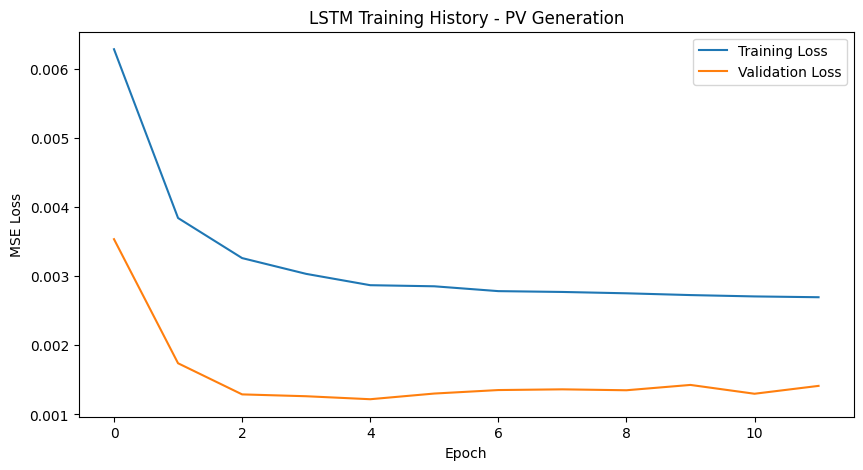

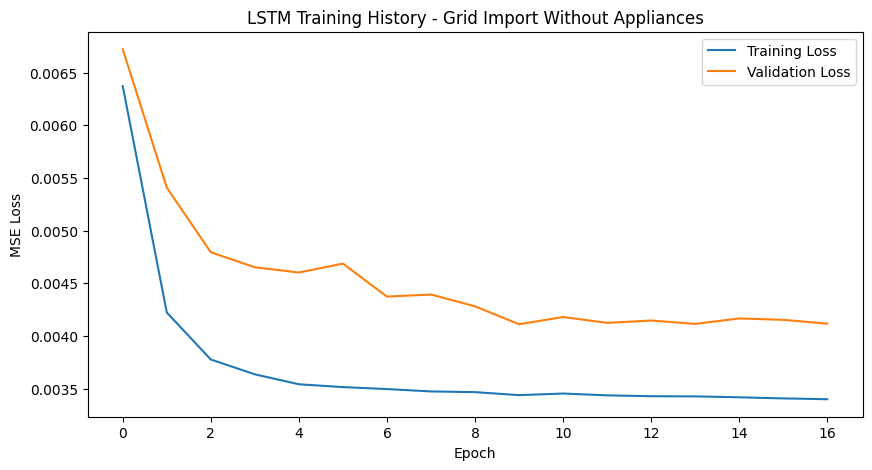

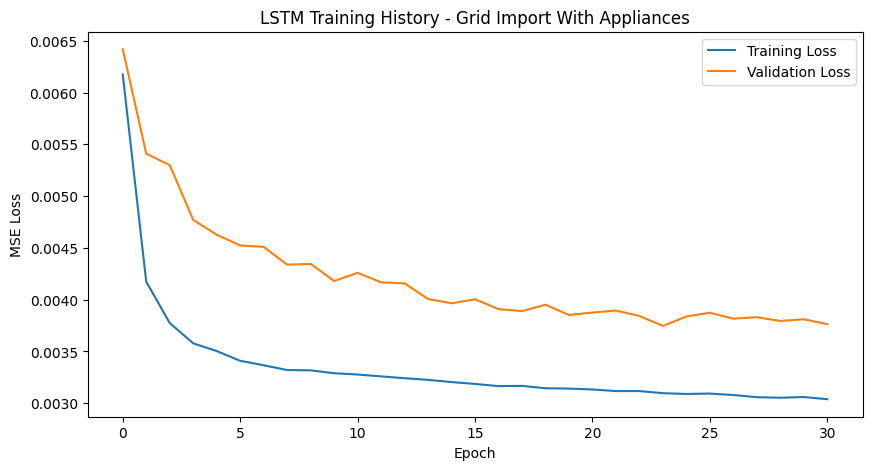

In [20]:
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()


plot_training_history(history_pv, "LSTM Training History - PV Generation")
plot_training_history(history_grid_no_app, "LSTM Training History - Grid Import Without Appliances")
plot_training_history(history_grid_app, "LSTM Training History - Grid Import With Appliances")

### Actual vs Predicted pv

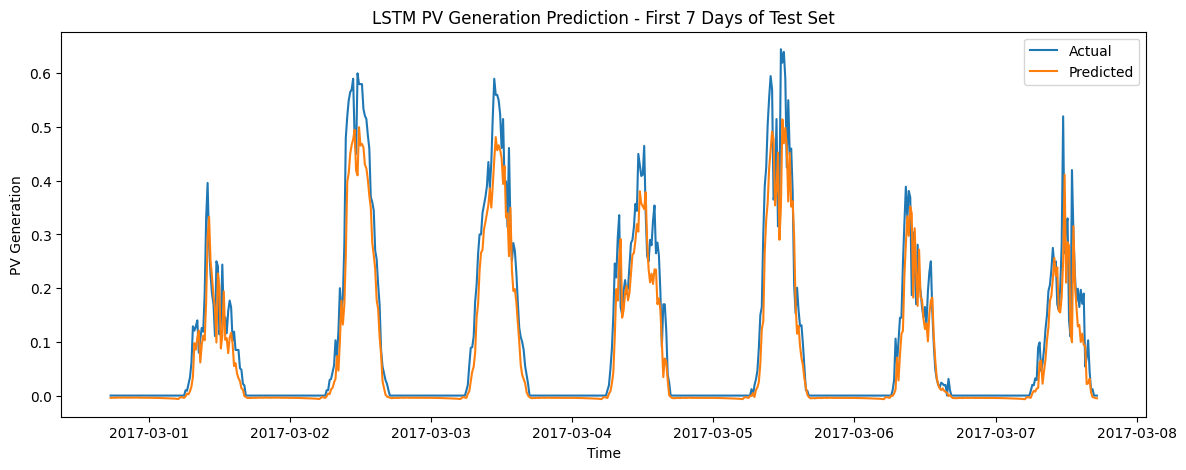

In [21]:
pv_plot = pd.DataFrame({
    "Actual": pv_actual,
    "Predicted": pv_pred
}, index=pv_data["test_target_times"])

pv_sample = pv_plot.iloc[:96 * 7]

plt.figure(figsize=(14, 5))
plt.plot(pv_sample.index, pv_sample["Actual"], label="Actual")
plt.plot(pv_sample.index, pv_sample["Predicted"], label="Predicted")
plt.title("LSTM PV Generation Prediction - First 7 Days of Test Set")
plt.xlabel("Time")
plt.ylabel("PV Generation")
plt.legend()
plt.show()

### Actual vs Predicted grid import

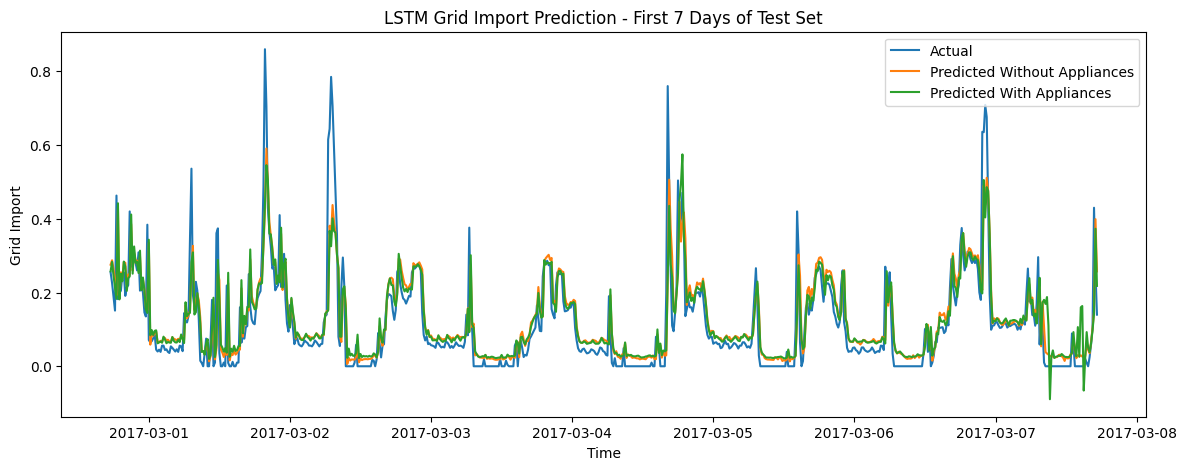

In [22]:
grid_plot = pd.DataFrame({
    "Actual": grid_actual,
    "Predicted Without Appliances": grid_pred_no_app,
    "Predicted With Appliances": grid_pred_app
}, index=grid_no_app_data["test_target_times"])

grid_sample = grid_plot.iloc[:96 * 7]

plt.figure(figsize=(14, 5))
plt.plot(grid_sample.index, grid_sample["Actual"], label="Actual")
plt.plot(
    grid_sample.index,
    grid_sample["Predicted Without Appliances"],
    label="Predicted Without Appliances"
)
plt.plot(
    grid_sample.index,
    grid_sample["Predicted With Appliances"],
    label="Predicted With Appliances"
)
plt.title("LSTM Grid Import Prediction - First 7 Days of Test Set")
plt.xlabel("Time")
plt.ylabel("Grid Import")
plt.legend()
plt.show()